<a href="https://colab.research.google.com/github/0923217130/Artificial-intelligence-model-for-internet-of-things-attack-detection/blob/main/workout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My\ Drive/Research/workout

/content/drive/My Drive/Research/workout


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
train = pd.read_csv('/content/drive/My Drive/Research/workout/exercise_angles.csv')    # reading the csv file
train.head()      # printing first five rows of the file
#print(train)

,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label
0,left,10.639208,174.466813,174.785143,179.848140,179.419276,90,90,90,90,90,Jumping Jacks
1,left,10.590342,174.428706,174.765041,179.775215,179.386147,90,90,90,90,90,Jumping Jacks
2,left,10.546746,174.489431,174.785790,179.660017,179.333710,90,90,90,90,90,Jumping Jacks
3,left,10.487682,174.614913,174.759542,179.614223,179.313926,90,90,90,90,90,Jumping Jacks
4,left,10.412107,174.758503,174.737721,179.570564,179.298805,90,90,90,90,90,Jumping Jacks


In [ ]:
print(f"Dataset Columns:\n{train.columns}")

Dataset Columns:
Index(['Side', 'Shoulder_Angle', 'Elbow_Angle', 'Hip_Angle', 'Knee_Angle',
       'Ankle_Angle', 'Shoulder_Ground_Angle', 'Elbow_Ground_Angle',
       'Hip_Ground_Angle', 'Knee_Ground_Angle', 'Ankle_Ground_Angle', 'Label'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train, test_size=0.2,random_state=20)

print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 24826 
The size of testing data is: 6207


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# possible values of a categorical features

In [ ]:

train['Label'] = encoder.fit_transform(train['Label'])
train.head(3000)

,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label
0,left,10.639208,174.466813,174.785143,179.848140,179.419276,90,90,90,90,90,0
1,left,10.590342,174.428706,174.765041,179.775215,179.386147,90,90,90,90,90,0
2,left,10.546746,174.489431,174.785790,179.660017,179.333710,90,90,90,90,90,0
3,left,10.487682,174.614913,174.759542,179.614223,179.313926,90,90,90,90,90,0
4,left,10.412107,174.758503,174.737721,179.570564,179.298805,90,90,90,90,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,left,143.456304,157.256762,173.583980,174.176487,177.854371,90,90,90,90,90,0
2996,left,104.943131,141.913351,174.659315,174.141534,176.659147,90,90,90,90,90,0
2997,left,56.363325,123.246529,175.825250,174.549188,175.706177,90,90,90,90,90,0
2998,left,32.906222,135.639646,177.095160,174.802013,174.850683,90,90,90,90,90,0


In [ ]:

train['Side'] = encoder.fit_transform(train['Side'])
train.head(3000)

,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label
0,0,10.639208,174.466813,174.785143,179.848140,179.419276,90,90,90,90,90,0
1,0,10.590342,174.428706,174.765041,179.775215,179.386147,90,90,90,90,90,0
2,0,10.546746,174.489431,174.785790,179.660017,179.333710,90,90,90,90,90,0
3,0,10.487682,174.614913,174.759542,179.614223,179.313926,90,90,90,90,90,0
4,0,10.412107,174.758503,174.737721,179.570564,179.298805,90,90,90,90,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,143.456304,157.256762,173.583980,174.176487,177.854371,90,90,90,90,90,0
2996,0,104.943131,141.913351,174.659315,174.141534,176.659147,90,90,90,90,90,0
2997,0,56.363325,123.246529,175.825250,174.549188,175.706177,90,90,90,90,90,0
2998,0,32.906222,135.639646,177.095160,174.802013,174.850683,90,90,90,90,90,0


In [ ]:
print(train.Label)

0        0
1        0
2        0
3        0
4        0
        ..
31028    3
31029    3
31030    3
31031    3
31032    3
Name: Label, Length: 31033, dtype: int64


In [ ]:

total = train["Label"].sum()
jumping_jacks = total -25824
pull_ups = total - 34374
push_ups= total - 21269
russian_twists= total - 26629
squats= total - 26036

print(train["Label"].value_counts())


Label
2    9764
1    6659
0    5209
4    4997
3    4404
Name: count, dtype: int64


Text(0.5, 0, 'Workout classes/ types percentage')

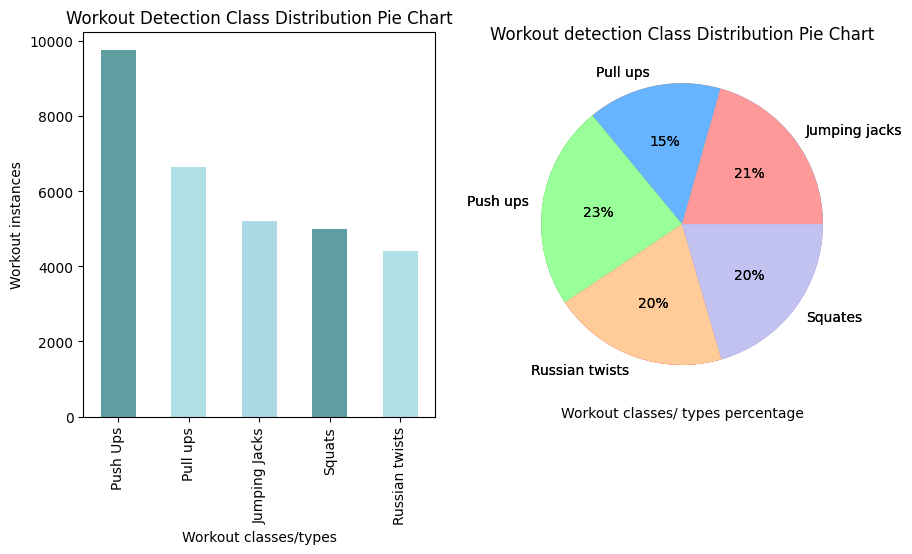

In [ ]:
train = pd.read_csv('/content/drive/My Drive/Research/workout/exercise_angles.csv')    # reading the csv file
plt.figure(figsize = (10,5))
plt.subplot(121)
# sns.countplot(x="fetal_health", data=data)
vis_CVD = train.Label.value_counts().plot(figsize=(10, 5), kind="bar", color = ["#5F9EA0", "#B0E0E6", "#ADD8E6"])
plt.title("Workout Detection Class Distribution Pie Chart")
plt.xlabel("Workout classes/types")
plt.ylabel("Workout instances")

plt.subplot(122)

plt.pie([jumping_jacks,pull_ups,push_ups, russian_twists,squats], labels=["Jumping jacks","Pull ups","Push ups", "Russian twists","Squates"], autopct="%1.0f%%")
plt.title("Workout state")

vis_pie_workout = plt.pie([jumping_jacks,pull_ups,push_ups, russian_twists,squats], labels=["Jumping jacks","Pull ups","Push ups", "Russian twists","Squates"], colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'], autopct="%1.0f%%")
plt.title("Workout detection Class Distribution Pie Chart")
plt.xlabel("Workout classes/ types percentage")

#plt.show()


In [ ]:
# Analyse statically insight of data
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Shoulder_Angle,31033.0,66.522206,60.226756,0.002748,17.852184,40.585632,121.209005,179.991577
Elbow_Angle,31033.0,114.303010,57.906279,0.000974,58.900491,132.999090,168.769517,179.998861
Hip_Angle,31033.0,137.466151,57.048278,0.006850,111.556724,168.374922,175.656498,179.999848
Knee_Angle,31033.0,143.273623,48.041715,0.116036,123.646144,168.227063,177.225089,179.999278
Ankle_Angle,31033.0,135.211957,53.304068,0.031297,106.740814,162.926184,175.735039,179.999942
Shoulder_Ground_Angle,31033.0,88.816743,14.546233,-90.000000,90.000000,90.000000,90.000000,90.000000
Elbow_Ground_Angle,31033.0,88.926949,13.856550,-90.000000,90.000000,90.000000,90.000000,90.000000
Hip_Ground_Angle,31033.0,79.408694,42.359381,-90.000000,90.000000,90.000000,90.000000,90.000000
Knee_Ground_Angle,31033.0,75.795121,48.530150,-90.000000,90.000000,90.000000,90.000000,90.000000
Ankle_Ground_Angle,31033.0,68.985596,57.802208,-90.000000,90.000000,90.000000,90.000000,90.000000


In [ ]:
# Count the missing and null values for dataset fetal healt.
miss_values = train.columns[train.isnull().any()]
print(f"Missing values:\n{train[miss_values].isnull().sum()}")

null_values = train.columns[train.isna().any()]
print(f"Null values:\n{train[null_values].isna().sum()}")

Missing values:
Series([], dtype: float64)
Null values:
Series([], dtype: float64)


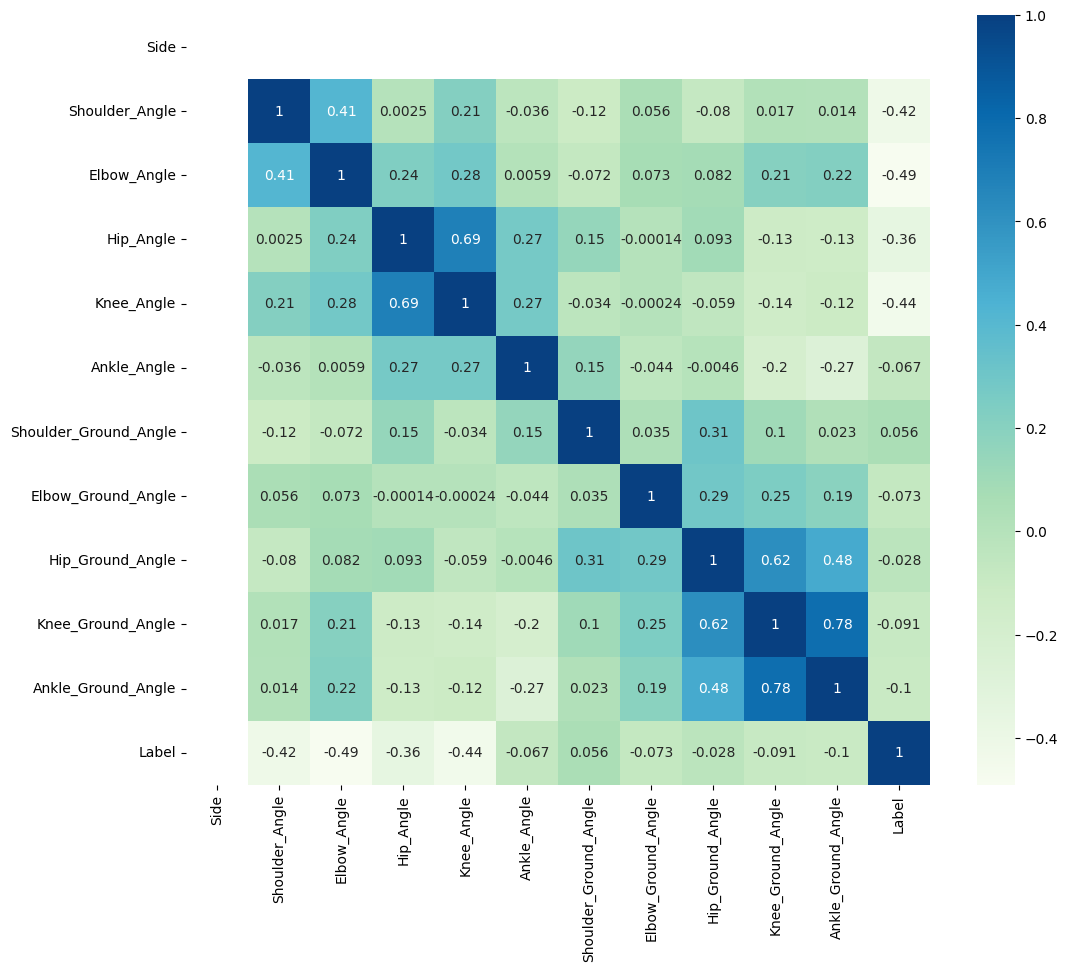

In [ ]:
# Set the size of figure to 12 by 10.
plt.figure(figsize=(12,10))

# Seaborn has very simple solution for heatmap
p=sns.heatmap(train.corr(), annot=True, cmap = "GnBu")

In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train, test_size=0.2,random_state=20)

print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 24826 
The size of testing data is: 6207


In [ ]:
X = train.drop(['Label'], axis=1)
y = train['Label']

# Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

tree_clf.fit(X_train,y_train)



DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

def accuracy(X_test,tree_clf,y_test):

    y_pred = tree_clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test,tree_clf, y_pred)))
    print(acc)

In [ ]:
y_pred=tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print('Accuracy: ' + repr(accuracy) + '%')

Accuracy: 93.00789431287257%


In [ ]:
from sklearn.metrics import classification_report
display(pd.DataFrame(classification_report(y_test, y_pred , output_dict =True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.921890,0.904580,0.971881,0.946429,0.875992,0.930079,0.924154,0.930282
recall,0.921002,0.913647,0.963019,0.948546,0.879482,0.930079,0.925139,0.930079
f1-score,0.921446,0.909091,0.967430,0.947486,0.877734,0.930079,0.924637,0.930168
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.930079,6207.000000,6207.000000


# Logestic regression

In [ ]:
# Import libraries, features and settings (not all of these are needed so pull what you need)

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import io
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn import preprocessing
plt.rc("font", size = 14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
sns.set(style="white")
sns.set(style="whitegrid", color_codes = True)
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train,y_train)
y_pred = logreg.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred)*100)

Accuracy: 69.46995327855647


In [ ]:
from sklearn.metrics import classification_report
display(pd.DataFrame(classification_report(y_test, y_pred , output_dict =True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.550820,0.486593,0.904659,0.823045,0.613762,0.6947,0.675776,0.699320
recall,0.647399,0.475713,0.845998,0.894855,0.550797,0.6947,0.682952,0.694700
f1-score,0.595217,0.481092,0.874346,0.857449,0.580577,0.6947,0.677736,0.695542
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.6947,6207.000000,6207.000000


# Gradient boosting algorithm

In [ ]:
# Import models and utility functions
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

# Setting SEED for reproducibility
SEED = 23

# Importing the dataset
X, y = load_digits(return_X_y=True)

# Splitting dataset
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = SEED)

# Instantiate Gradient Boosting Regressor
gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )
# Fit to training set
gbc.fit(train_X, train_y)

# Predict on test set
pred_y = gbc.predict(test_X)

# accuracy
acc = accuracy_score(test_y, pred_y)*100
print("Gradient Boosting Classifier accuracy is : {:.4f}".format(acc))

Gradient Boosting Classifier accuracy is : 97.7778


In [ ]:
from sklearn.metrics import classification_report
display(pd.DataFrame(classification_report(test_y, pred_y , output_dict =True)))

,0,1,2,3,4,5,6,7,8,9,accuracy,macro avg,weighted avg
precision,1.0,0.975,1.0,0.966667,1.000000,0.955556,1.0,0.964286,0.972973,0.953488,0.977778,0.978797,0.978048
recall,1.0,0.975,1.0,1.000000,0.950000,0.977273,1.0,0.964286,0.947368,0.976190,0.977778,0.979012,0.977778
f1-score,1.0,0.975,1.0,0.983051,0.974359,0.966292,1.0,0.964286,0.960000,0.964706,0.977778,0.978769,0.977770
support,30.0,40.000,38.0,29.000000,40.000000,44.000000,31.0,28.000000,38.000000,42.000000,0.977778,360.000000,360.000000


# Random forest

In [ ]:
#Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier
#Create a Gaussian Classifier
clf=RandomForestClassifier(n_estimators=100)
#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
# Predicting the test set results
y_pred = clf.predict(X_test)

# accuracy
acc = accuracy_score(test_y, pred_y)*100
print("Random Forest Classifier accuracy is : {:.4f}".format(acc))

Random Forest Classifier accuracy is : 97.7778


In [ ]:
from sklearn.metrics import classification_report
display(pd.DataFrame(classification_report(y_test, y_pred , output_dict =True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.963107,0.952816,0.969170,0.973952,0.946336,0.961817,0.961076,0.961734
recall,0.955684,0.965305,0.987335,0.961969,0.913347,0.961817,0.956728,0.961817
f1-score,0.959381,0.959020,0.978168,0.967923,0.929549,0.961817,0.958808,0.961685
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.961817,6207.000000,6207.000000


# Bagging

In [ ]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 20

X = train.drop(['Label'], axis=1)
y = train['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(19860, 11) (4966, 11) (6207, 11)
(19860,) (4966,) (6207,)


In [ ]:
%%time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

pipe_svc = Pipeline([('scl', StandardScaler()),
                     ('pca', PCA(n_components=0.8, random_state = RANDOM_STATE)),
                     ('clf', SVC(kernel='rbf', random_state=RANDOM_STATE))])

bag = BaggingClassifier(estimator=pipe_svc,
                        n_estimators=10,
                        max_samples=0.5,
                        max_features=0.5,
                        bootstrap=True,
                        bootstrap_features=True,
                        oob_score=True,
                        warm_start=False,
                        n_jobs=-1,
                        random_state=RANDOM_STATE)
bag.fit(X_train, y_train)

CPU times: user 58.6 s, sys: 253 ms, total: 58.8 s
Wall time: 2min 15s


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:875: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:881: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


BaggingClassifier(bootstrap_features=True,
                  estimator=Pipeline(steps=[('scl', StandardScaler()),
                                            ('pca',
                                             PCA(n_components=0.8,
                                                 random_state=20)),
                                            ('clf', SVC(random_state=20))]),
                  max_features=0.5, max_samples=0.5, n_jobs=-1, oob_score=True,
                  random_state=20)

In [ ]:
y_pred = bag.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict =True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.668063,0.689619,0.640343,0.841509,0.826087,0.684253,0.733124,0.715602
recall,0.778049,0.592896,0.988079,0.612637,0.211111,0.684253,0.636555,0.684253
f1-score,0.718873,0.637610,0.777083,0.709062,0.336283,0.684253,0.635782,0.654763
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.684253,4966.000000,4966.000000


In [ ]:
y_pred = bag.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict =True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.667500,0.699208,0.664166,0.868035,0.862745,0.701788,0.752331,0.733530
recall,0.771676,0.612953,0.986829,0.662192,0.219124,0.701788,0.650555,0.701788
f1-score,0.715818,0.653246,0.793968,0.751269,0.349484,0.701788,0.652757,0.673447
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.701788,6207.000000,6207.000000


In [ ]:
from imblearn.ensemble import BalancedBaggingClassifier

bal_bag = BalancedBaggingClassifier(estimator=pipe_svc,
                                n_estimators=10,
                                max_samples=0.5,
                                max_features=0.5,
                                bootstrap=True,
                                bootstrap_features=True,
                                oob_score=True,
                                warm_start=False,
                                sampling_strategy ='majority',
                                replacement=True,
                                n_jobs=-1,
                                random_state=RANDOM_STATE)
bal_bag.fit(X_train, y_train)

y_pred = bal_bag.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict =True)))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:875: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:881: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.373175,0.633712,0.883150,0.775036,0.797909,0.607128,0.692596,0.714037
recall,0.997561,0.356102,0.690728,0.733516,0.282716,0.607128,0.612125,0.607128
f1-score,0.543161,0.455977,0.775177,0.753705,0.417502,0.607128,0.589104,0.604802
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.607128,4966.000000,4966.000000


In [ ]:
from imblearn.ensemble import BalancedBaggingClassifier

bal_bag = BalancedBaggingClassifier(estimator=pipe_svc,
                                n_estimators=10,
                                max_samples=0.5,
                                max_features=0.5,
                                bootstrap=True,
                                bootstrap_features=True,
                                oob_score=True,
                                warm_start=False,
                                sampling_strategy ='majority',
                                replacement=True,
                                n_jobs=-1,
                                random_state=RANDOM_STATE)
bal_bag.fit(X_train, y_train)

y_pred = bal_bag.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict =True)))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:875: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_bagging.py:881: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.373869,0.625832,0.892979,0.787330,0.842105,0.611729,0.704423,0.726900
recall,0.995183,0.362375,0.663627,0.778523,0.286853,0.611729,0.617312,0.611729
f1-score,0.543541,0.458984,0.761407,0.782902,0.427935,0.611729,0.594954,0.610935
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.611729,6207.000000,6207.000000


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(criterion='gini',
                                n_estimators=1000,
                                max_features = 'sqrt',
                                class_weight = 'balanced',
                                random_state=RANDOM_STATE,
                                n_jobs=-1)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.973750,0.944742,0.970722,0.988685,0.942500,0.963351,0.964080,0.963508
recall,0.950000,0.965392,0.988079,0.960165,0.930864,0.963351,0.958900,0.963351
f1-score,0.961728,0.954955,0.979324,0.974216,0.936646,0.963351,0.961374,0.963320
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.963351,4966.000000,4966.000000


In [ ]:
y_pred = forest.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.960348,0.952708,0.968734,0.974011,0.953222,0.962301,0.961805,0.962234
recall,0.956647,0.962992,0.988855,0.964206,0.913347,0.962301,0.957209,0.962301
f1-score,0.958494,0.957822,0.978691,0.969084,0.932859,0.962301,0.959390,0.962156
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.962301,6207.000000,6207.000000


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

# create a forest classifier
ETSC = ExtraTreesClassifier(criterion='gini',
                            n_estimators=1000,
                            max_features = 'sqrt',
                            class_weight = 'balanced',
                            random_state=RANDOM_STATE,
                            n_jobs=-1)

ETSC.fit(X_train, y_train)

y_pred = ETSC.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred, output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.976309,0.958333,0.971987,0.987324,0.944785,0.967378,0.967748,0.967493
recall,0.954878,0.963570,0.988079,0.962912,0.950617,0.967378,0.964011,0.967378
f1-score,0.965475,0.960945,0.979967,0.974965,0.947692,0.967378,0.965809,0.967371
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.967378,4966.000000,4966.000000


In [ ]:
y_pred = ETSC.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred, output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.965116,0.957088,0.969772,0.980704,0.959835,0.966328,0.966503,0.966310
recall,0.959538,0.962992,0.991388,0.966443,0.928287,0.966328,0.961729,0.966328
f1-score,0.962319,0.960031,0.980461,0.973521,0.943797,0.966328,0.964026,0.966228
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.966328,6207.000000,6207.000000


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

bal_forest = BalancedRandomForestClassifier(criterion='gini',
                                            n_estimators=1000,
                                            max_features = 'sqrt',
                                            random_state=RANDOM_STATE,
                                            n_jobs=-1
                                            )
bal_forest.fit(X_train, y_train)

y_pred = bal_forest.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.961963,0.948276,0.973044,0.979021,0.929889,0.959525,0.958439,0.959575
recall,0.956098,0.951730,0.980132,0.961538,0.933333,0.959525,0.956566,0.959525
f1-score,0.959021,0.950000,0.976575,0.970201,0.931608,0.959525,0.957481,0.959532
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.959525,4966.000000,4966.000000


In [ ]:
y_pred = bal_forest.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.958614,0.958493,0.973909,0.971847,0.941176,0.962623,0.960808,0.962538
recall,0.959538,0.961449,0.983283,0.965324,0.924303,0.962623,0.958779,0.962623
f1-score,0.959076,0.959969,0.978573,0.968575,0.932663,0.962623,0.959771,0.962559
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.962623,6207.000000,6207.000000


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree_reg1 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg1.fit(X_train, y_train)

y_train2 = y_train - tree_reg1.predict(X_train)
tree_reg2 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg2.fit(X_train, y_train2)

y_train3 = y_train2 - tree_reg2.predict(X_train)
tree_reg3 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg3.fit(X_train, y_train3)

y_pred = sum(tree.predict(X_val) for tree in (tree_reg1, tree_reg2, tree_reg3))

pd.DataFrame(classification_report(y_val, y_pred , output_dict =True))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.428571,0.733333,0.804910,0.897690,0.530864,0.0,0.629078,0.565895,0.695844
recall,0.921951,0.490893,0.803311,0.373626,0.424691,0.0,0.629078,0.502412,0.629078
f1-score,0.585139,0.588107,0.804110,0.527643,0.471879,0.0,0.629078,0.496146,0.625475
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.0,0.629078,4966.000000,4966.000000


In [ ]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

pd.DataFrame(classification_report(y_test, y_pred , output_dict =True))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.431399,0.715096,0.812757,0.890625,0.545220,0.0,0.633639,0.565850,0.696516
recall,0.923892,0.485736,0.800405,0.382550,0.420319,0.0,0.633639,0.502150,0.633639
f1-score,0.588163,0.578512,0.806534,0.535211,0.474691,0.0,0.633639,0.497185,0.629613
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.0,0.633639,6207.000000,6207.000000


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier(max_depth = 2, n_estimators=3,
                                 learning_rate=1.0, random_state=RANDOM_STATE)
GBC.fit(X_train, y_train)
y_pred = GBC.predict(X_val)
pd.DataFrame(classification_report(y_val, y_pred , output_dict = True))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.715976,0.795359,0.892630,0.825553,0.740260,0.808095,0.793956,0.807267
recall,0.885366,0.686703,0.930464,0.923077,0.562963,0.808095,0.797714,0.808095
f1-score,0.791712,0.737048,0.911154,0.871595,0.639551,0.808095,0.790212,0.802836
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.808095,4966.000000,4966.000000


In [ ]:
y_pred = GBC.predict(X_test)
pd.DataFrame(classification_report(y_test, y_pred , output_dict = True))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.717829,0.794092,0.905547,0.810328,0.712401,0.806831,0.788040,0.805909
recall,0.892100,0.704703,0.917933,0.912752,0.537849,0.806831,0.793067,0.806831
f1-score,0.795533,0.746732,0.911698,0.858496,0.612940,0.806831,0.785080,0.801813
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.806831,6207.000000,6207.000000


# Majority voting

In [ ]:
%%time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import NeighbourhoodCleaningRule
from sklearn.decomposition import PCA
import timeit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, make_scorer
scoring = {'accuracy': make_scorer(accuracy_score),
           'precision': make_scorer(precision_score, average = 'macro'),
           'recall': make_scorer(recall_score, average = 'macro'),
           'f1_macro': make_scorer(f1_score, average = 'macro'),
           'f1_weighted': make_scorer(f1_score, average = 'weighted')}

clf1 = Pipeline([('scl', StandardScaler()),
                 ('clf', SVC(kernel='rbf',
                             gamma='auto',
                             random_state=RANDOM_STATE,
                             probability = True))])

clf2 = Pipeline([('scl', StandardScaler()),
                 ('clf', LogisticRegression(solver='liblinear',
                                            random_state=RANDOM_STATE))
])

clf3 = DecisionTreeClassifier(random_state=RANDOM_STATE)

clf_labels = ['SVM', # Support Vector Machine
              'LR', # LogisticRegression
              'DT'] # Decision Tree

# Majority Rule Voting
hard_mv_clf = VotingClassifier(estimators=[(clf_labels[0],clf1),
                                           (clf_labels[1],clf2),
                                           (clf_labels[2],clf3)],
                               voting='hard')

soft_mv_clf = VotingClassifier(estimators=[(clf_labels[0],clf1),
                                           (clf_labels[1],clf2),
                                           (clf_labels[2],clf3)],
                               voting='soft')

clf_labels += ['Hard Majority Voting', 'Soft Majority Voting']
all_clf = [clf1, clf2, clf3, hard_mv_clf, soft_mv_clf]

#print(color.BOLD+color.UNDERLINE+'Validation Scores\n'+color.END)
for clf, label in zip(all_clf, clf_labels):
    start = timeit.default_timer() # TIME STUFF

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)
    scores = accuracy_score(y_val, y_pred)
   # print(color.BOLD+label+color.END)
    print("Score: %0.4f"
          % scores)
    # TIME STUFF
    stop = timeit.default_timer()
    print("Run time:", np.round((stop-start)/60,2),"minutes")
    print()

Score: 0.8762
Run time: 0.68 minutes

Score: 0.7306
Run time: 0.01 minutes

Score: 0.9323
Run time: 0.0 minutes

Score: 0.8899
Run time: 0.56 minutes

Score: 0.9267
Run time: 0.55 minutes

CPU times: user 1min 41s, sys: 2.49 s, total: 1min 44s
Wall time: 1min 47s


In [ ]:
display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.903110,0.901168,0.958199,0.963277,0.891247,0.926702,0.923400,0.926317
recall,0.920732,0.913479,0.986755,0.936813,0.829630,0.926702,0.917482,0.926702
f1-score,0.911836,0.907282,0.972268,0.949861,0.859335,0.926702,0.920116,0.926215
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.926702,4966.000000,4966.000000


In [ ]:
%%time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import NeighbourhoodCleaningRule
from sklearn.decomposition import PCA
import timeit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, make_scorer
scoring = {'accuracy': make_scorer(accuracy_score),
           'precision': make_scorer(precision_score, average = 'macro'),
           'recall': make_scorer(recall_score, average = 'macro'),
           'f1_macro': make_scorer(f1_score, average = 'macro'),
           'f1_weighted': make_scorer(f1_score, average = 'weighted')}

clf1 = Pipeline([('scl', StandardScaler()),
                 ('clf', SVC(kernel='rbf',
                             gamma='auto',
                             random_state=RANDOM_STATE,
                             probability = True))])

clf2 = Pipeline([('scl', StandardScaler()),
                 ('clf', LogisticRegression(solver='liblinear',
                                            random_state=RANDOM_STATE))
])

clf3 = DecisionTreeClassifier(random_state=RANDOM_STATE)

clf_labels = ['SVM', # Support Vector Machine
              'LR', # LogisticRegression
              'DT'] # Decision Tree

# Majority Rule Voting
hard_mv_clf = VotingClassifier(estimators=[(clf_labels[0],clf1),
                                           (clf_labels[1],clf2),
                                           (clf_labels[2],clf3)],
                               voting='hard')

soft_mv_clf = VotingClassifier(estimators=[(clf_labels[0],clf1),
                                           (clf_labels[1],clf2),
                                           (clf_labels[2],clf3)],
                               voting='soft')

clf_labels += ['Hard Majority Voting', 'Soft Majority Voting']
all_clf = [clf1, clf2, clf3, hard_mv_clf, soft_mv_clf]


#print(color.fontweight+color.UNDERLINE+'Validation Scores\n'+color.END)
for clf, label in zip(all_clf, clf_labels):
    start = timeit.default_timer() # TIME STUFF

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    scores = accuracy_score(y_test, y_pred)
    #print(color.fontweight+label+color.END)
    print("Score: %0.3f"
          % scores)
    # TIME STUFF
    stop = timeit.default_timer()
    print("Run time:", np.round((stop-start)/60,2),"minutes")
    print()

Score: 0.878
Run time: 0.78 minutes

Score: 0.734
Run time: 0.01 minutes

Score: 0.931
Run time: 0.0 minutes

Score: 0.888
Run time: 0.57 minutes

Score: 0.924
Run time: 0.58 minutes

CPU times: user 1min 47s, sys: 2.33 s, total: 1min 49s
Wall time: 1min 56s


In [ ]:
display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.900563,0.899160,0.960140,0.955932,0.875532,0.923635,0.918265,0.923143
recall,0.924855,0.907479,0.976190,0.946309,0.819721,0.923635,0.914911,0.923635
f1-score,0.912548,0.903300,0.968098,0.951096,0.846708,0.923635,0.916350,0.923184
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.923635,6207.000000,6207.000000


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Features (X) and labels (y)
X = train.drop('Label', axis=1)  # Assuming 'Class' is the target column
y = train['Label']

# Label encoding for multi-class ROC
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Binarize the output (one-vs-rest for multi-class)
y_bin = label_binarize(y_encoded, classes=list(range(len(le.classes_))))

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a One-vs-Rest Random Forest Classifier
classifier = OneVsRestClassifier(RandomForestClassifier(random_state=42))
classifier.fit(X_train, y_train)

# Get the predicted probabilities
y_score = classifier.predict_proba(X_test)

# Plot ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Multi-Class ROC Curve', fontweight='bold', fontsize=16)
plt.legend(loc="lower right")
plt.show()

# Boosting

# Gradient boosting

In [ ]:
%%time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

tree = DecisionTreeClassifier(criterion='gini',
                              max_depth=1,
                              random_state=RANDOM_STATE)

ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=100,
                         learning_rate=0.1,
                         random_state=RANDOM_STATE)

ada.fit(X_train, y_train)

y_pred = ada.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.581376,0.636508,0.787464,0.772260,0.559006,0.680024,0.667323,0.680565
recall,0.845122,0.365209,0.915232,0.619505,0.555556,0.680024,0.660125,0.680024
f1-score,0.688867,0.464120,0.846554,0.687500,0.557276,0.680024,0.648863,0.665458
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.680024,4966.000000,4966.000000


CPU times: user 4.09 s, sys: 10.7 ms, total: 4.1 s
Wall time: 6.87 s


In [ ]:
%%time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

tree = DecisionTreeClassifier(criterion='gini',
                              max_depth=1,
                              random_state=RANDOM_STATE)

ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=100,
                         learning_rate=0.1,
                         random_state=RANDOM_STATE)

ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.583553,0.607242,0.803571,0.808625,0.549139,0.687127,0.670426,0.685326
recall,0.854528,0.336160,0.911854,0.671141,0.539841,0.687127,0.662705,0.687127
f1-score,0.693511,0.432754,0.854295,0.733496,0.544450,0.687127,0.651701,0.671806
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.687127,6207.000000,6207.000000


CPU times: user 4.08 s, sys: 15 ms, total: 4.09 s
Wall time: 6.27 s


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report



tree_reg1 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg1.fit(X_train, y_train)

y_train2 = y_train - tree_reg1.predict(X_train)
tree_reg2 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg2.fit(X_train, y_train2)

y_train3 = y_train2 - tree_reg2.predict(X_train)
tree_reg3 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tree_reg3.fit(X_train, y_train3)

y_pred = sum(tree.predict(X_val) for tree in (tree_reg1, tree_reg2, tree_reg3))

pd.DataFrame(classification_report(y_val, y_pred , output_dict =True))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.428571,0.733333,0.804910,0.897690,0.530864,0.0,0.629078,0.565895,0.695844
recall,0.921951,0.490893,0.803311,0.373626,0.424691,0.0,0.629078,0.502412,0.629078
f1-score,0.585139,0.588107,0.804110,0.527643,0.471879,0.0,0.629078,0.496146,0.625475
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.0,0.629078,4966.000000,4966.000000


In [ ]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

pd.DataFrame(classification_report(y_test, y_pred , output_dict =True))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.431399,0.715096,0.812757,0.890625,0.545220,0.0,0.633639,0.565850,0.696516
recall,0.923892,0.485736,0.800405,0.382550,0.420319,0.0,0.633639,0.502150,0.633639
f1-score,0.588163,0.578512,0.806534,0.535211,0.474691,0.0,0.633639,0.497185,0.629613
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.0,0.633639,6207.000000,6207.000000


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier(max_depth = 2, n_estimators=3,
                                 learning_rate=1.0, random_state=RANDOM_STATE)
GBC.fit(X_train, y_train)
y_pred = GBC.predict(X_val)
pd.DataFrame(classification_report(y_val, y_pred , output_dict = True))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.715976,0.795359,0.892630,0.825553,0.740260,0.808095,0.793956,0.807267
recall,0.885366,0.686703,0.930464,0.923077,0.562963,0.808095,0.797714,0.808095
f1-score,0.791712,0.737048,0.911154,0.871595,0.639551,0.808095,0.790212,0.802836
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.808095,4966.000000,4966.000000


In [ ]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

pd.DataFrame(classification_report(y_test, y_pred , output_dict =True))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.431399,0.715096,0.812757,0.890625,0.545220,0.0,0.633639,0.565850,0.696516
recall,0.923892,0.485736,0.800405,0.382550,0.420319,0.0,0.633639,0.502150,0.633639
f1-score,0.588163,0.578512,0.806534,0.535211,0.474691,0.0,0.633639,0.497185,0.629613
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.0,0.633639,6207.000000,6207.000000


# Stochastic Gradient Boosting

In [ ]:
gbrt = GradientBoostingClassifier(max_depth=2, warm_start=True, subsample = 0.5, random_state=RANDOM_STATE)

max_val_score = float(0)
score_not_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_val)
    val_score = accuracy_score(y_val, y_pred)
    if val_score > max_val_score:
        max_val_score = val_score
        score_not_going_up = 0
    else:
        score_not_going_up += 1
        if score_not_going_up == 5:
            break  # early stopping

print("Number of estimators:", gbrt.n_estimators)
print("Maximum Accuracy:", max_val_score)


Number of estimators: 119
Maximum Accuracy: 0.8848167539267016


In [ ]:
pd.DataFrame(classification_report(y_val, y_pred , output_dict =True))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.852839,0.844679,0.918444,0.948468,0.844920,0.884817,0.881870,0.883710
recall,0.897561,0.802368,0.969536,0.935440,0.780247,0.884817,0.877030,0.884817
f1-score,0.874629,0.822980,0.943299,0.941909,0.811297,0.884817,0.878823,0.883622
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.884817,4966.000000,4966.000000


In [ ]:
gbrt = GradientBoostingClassifier(max_depth=2, warm_start=True, subsample = 0.5, random_state=RANDOM_STATE)

max_val_score = float(0)
score_not_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_test)
    val_score = accuracy_score(y_test, y_pred)
    if val_score > max_val_score:
        max_val_score = val_score
        score_not_going_up = 0
    else:
        score_not_going_up += 1
        if score_not_going_up == 5:
            break  # early stopping

print("Number of estimators:", gbrt.n_estimators)
print("Maximum Accuracy:", max_val_score)


Number of estimators: 115
Maximum Accuracy: 0.8867407765426132


In [ ]:
pd.DataFrame(classification_report(y_test, y_pred , output_dict =True))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.851512,0.851493,0.929509,0.927152,0.832604,0.885613,0.878454,0.884149
recall,0.894990,0.813416,0.968592,0.939597,0.757968,0.885613,0.874913,0.885613
f1-score,0.872710,0.832019,0.948648,0.933333,0.793535,0.885613,0.876049,0.884283
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.885613,6207.000000,6207.000000


# XgBoost

In [ ]:
from xgboost import XGBClassifier

%timeit XGBClassifier(n_estimators =10, random_state=RANDOM_STATE).fit(X_train, y_train)

197 ms ± 7.98 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

%timeit AdaBoostClassifier(n_estimators =10, random_state=RANDOM_STATE).fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

736 ms ± 81.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit GradientBoostingClassifier(n_estimators =10, random_state=RANDOM_STATE).fit(X_train, y_train)

4.57 s ± 1.54 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
XGmodel = XGBClassifier(max_depth = 3,
                        learning_rate = 0.1,
                        n_estimators=500,
                        booster = 'gbtree',
                        n_jobs =-1,
                        random_state=RANDOM_STATE)

XGmodel.fit(X_train, y_train)

y_pred = XGmodel.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.934227,0.907207,0.957447,0.978903,0.915912,0.938985,0.938739,0.938875
recall,0.935366,0.917122,0.983444,0.956044,0.874074,0.938985,0.933210,0.938985
f1-score,0.934796,0.912138,0.970271,0.967338,0.894504,0.938985,0.935809,0.938772
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.938985,4966.000000,4966.000000


In [ ]:
XGmodel = XGBClassifier(max_depth = 3,
                        learning_rate = 0.1,
                        n_estimators=500,
                        booster = 'gbtree',
                        n_jobs =-1,
                        random_state=RANDOM_STATE)

XGmodel.fit(X_train, y_train)

y_pred = XGmodel.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.923295,0.908202,0.962668,0.965870,0.912206,0.937168,0.934448,0.937001
recall,0.939306,0.930609,0.979737,0.949664,0.848606,0.937168,0.929584,0.937168
f1-score,0.931232,0.919269,0.971127,0.957699,0.879257,0.937168,0.931717,0.936825
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.937168,6207.000000,6207.000000


# LightGBM

In [ ]:
from lightgbm import LGBMClassifier

%timeit LGBMClassifier(n_estimators =10, random_state=RANDOM_STATE).fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 19860, number of used features: 10
[LightGBM] [Info] Start training from score -1.779449
[LightGBM] [Info] Start training from score -1.538500
[LightGBM] [Info] Start training from score -1.151338
[LightGBM] [Info] Start training from score -1.965538
[LightGBM] [Info] Start training from score -1.830884
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 19860, number of used features: 10
[LightGBM] [Info] Start 

In [ ]:
LGBM_model = LGBMClassifier(boosting_type='gbdt',
                            max_depth=3,
                            n_estimators=500,
                            random_state=RANDOM_STATE,
                            neg_bagging_fraction = 0.5, # for subsampling interictal data
                            n_jobs =-1,
                            bagging_seed = RANDOM_STATE)

LGBM_model.fit(X_train, y_train)

y_pred = LGBM_model.predict(X_val)

display(pd.DataFrame(classification_report(y_val, y_pred , output_dict = True)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 19860, number of used features: 10
[LightGBM] [Info] Start training from score -1.779449
[LightGBM] [Info] Start training from score -1.538500
[LightGBM] [Info] Start training from score -1.151338
[LightGBM] [Info] Start training from score -1.965538
[LightGBM] [Info] Start training from score -1.830884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.948941,0.916890,0.963011,0.981664,0.914358,0.945228,0.944973,0.945289
recall,0.929268,0.934426,0.982781,0.956044,0.896296,0.945228,0.939763,0.945228
f1-score,0.939002,0.925575,0.972796,0.968685,0.905237,0.945228,0.942259,0.945153
support,820.000000,1098.000000,1510.000000,728.000000,810.000000,0.945228,4966.000000,4966.000000


In [ ]:
LGBM_model = LGBMClassifier(boosting_type='gbdt',
                            max_depth=3,
                            n_estimators=500,
                            random_state=RANDOM_STATE,
                            neg_bagging_fraction = 0.5, # for subsampling interictal data
                            n_jobs =-1,
                            bagging_seed = RANDOM_STATE)

LGBM_model.fit(X_train, y_train)

y_pred = LGBM_model.predict(X_test)

display(pd.DataFrame(classification_report(y_test, y_pred , output_dict = True)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 19860, number of used features: 10
[LightGBM] [Info] Start training from score -1.779449
[LightGBM] [Info] Start training from score -1.538500
[LightGBM] [Info] Start training from score -1.151338
[LightGBM] [Info] Start training from score -1.965538
[LightGBM] [Info] Start training from score -1.830884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.935238,0.922433,0.965569,0.969526,0.926471,0.945868,0.943847,0.945729
recall,0.946050,0.935235,0.980243,0.960850,0.878486,0.945868,0.940173,0.945868
f1-score,0.940613,0.928790,0.972851,0.965169,0.901840,0.945868,0.941853,0.945660
support,1038.000000,1297.000000,1974.000000,894.000000,1004.000000,0.945868,6207.000000,6207.000000
